# Used Car Price Prediction

**Track:** Data Science &nbsp;|&nbsp; **Task:** 3 — Car Price Prediction with Machine Learning
**Author:** **Youssef Laaroussi** &nbsp;|&nbsp; **Program:** Oasis Infobyte SIP

## Objective

Build a regression model that predicts the selling price of a used car from
its brand, age, mileage, fuel type, transmission, seller type, and ownership
history.

## Dataset

**Source:** "Vehicle dataset from CarDekho" — publicly available on Kaggle
(search "CAR DETAILS FROM CAR DEKHO" on kaggle.com, or use the CSV shipped
alongside this notebook).

- **Rows / Columns (raw):** 4,340 listings, 8 columns
- **Columns:** `name`, `year`, `selling_price`, `km_driven`, `fuel`,
  `seller_type`, `transmission`, `owner`

## Project Structure & Analytical Pipeline

| # | Analysis Phase | Where it's done |
|---|---|---|
| 1 | Download a suitable dataset | Section 2 |
| 2 | Data cleaning: null values, duplicates, inconsistent categories | Section 3 |
| 3 | Feature engineering: car age from year, brand from name | Section 4 |
| 4 | EDA: price distribution, price vs. fuel boxplot, price vs. age scatter | Section 5 |
| 5 | Encode categorical variables | Section 6 |
| 6 | Feature correlation heatmap | Section 7 |
| 7 | Train/test split | Section 8 |
| 8 | Train at least 2 regression models | Section 9 |
| 9 | Evaluate: MAE, RMSE, R² | Section 10 |
| 10 | Feature importance chart for the best model | Section 11 |
| 11 | Clean, commented Jupyter Notebook | Throughout |

## Table of Contents
1. [Environment Setup](#1)
2. [Data Sourcing & Loading](#2)
3. [Data Cleaning](#3)
   - 3.1 [Initial Inspection](#31)
   - 3.2 [Null Value Check](#32)
   - 3.3 [Duplicate Removal](#33)
   - 3.4 [Categorical Consistency Check](#34)
4. [Feature Engineering](#4)
   - 4.1 [Car Age](#41)
   - 4.2 [Brand Extraction](#42)
5. [Exploratory Data Analysis](#5)
   - 5.1 [Distribution of Selling Price](#51)
   - 5.2 [Price vs. Fuel Type](#52)
   - 5.3 [Price vs. Car Age](#53)
6. [Encoding Categorical Variables](#6)
7. [Feature Correlation Heatmap](#7)
8. [Train / Test Split](#8)
9. [Model Training](#9)
10. [Model Evaluation](#10)
11. [Feature Importance](#11)
12. [Conclusion](#12)
13. [References](#13)


<a id='1'></a>
## 1. Environment Setup & Imports

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Model selection & preprocessing
from sklearn.model_selection import train_test_split

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproducibility & display settings
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100

print("Libraries imported successfully.")


Libraries imported successfully.


<a id='2'></a>
## 2. Data Sourcing & Loading


The dataset was sourced from Kaggle ("Vehicle dataset from CarDekho" — search
that phrase on kaggle.com to download it yourself). To keep this notebook
self-contained on Google Colab, the CSV (`CAR DETAILS FROM CAR DEKHO.csv`) is
shipped alongside it — place it in the same folder before running. If it
isn't found, the cell below automatically opens a Colab upload widget.

In [2]:
DATA_PATH = "CAR DETAILS FROM CAR DEKHO.csv"

try:
    raw_df = pd.read_csv(DATA_PATH)
    print(f"Loaded '{DATA_PATH}' from the local working directory.")
except FileNotFoundError:
    try:
        from google.colab import files
        print(f"'{DATA_PATH}' not found locally — please upload it now.")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
        raw_df = pd.read_csv(DATA_PATH)
    except ImportError:
        raise FileNotFoundError(
            f"Could not find '{DATA_PATH}'. Download 'CAR DETAILS FROM CAR DEKHO.csv' "
            "from Kaggle and place it next to this notebook."
        )

print(f"Rows x Columns (raw): {raw_df.shape}")
raw_df.head()


Loaded 'CAR DETAILS FROM CAR DEKHO.csv' from the local working directory.
Rows x Columns (raw): (4340, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


<a id='3'></a>
## 3. Data Cleaning

<a id='31'></a>
### 3.1 Initial Inspection

with.

In [3]:
print(f"Shape: {raw_df.shape[0]} rows x {raw_df.shape[1]} columns\n")
raw_df.info()


Shape: 4340 rows x 8 columns

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


<a id='32'></a>
### 3.2 Null Value Check



In [4]:
print("Missing values per column:")
print(raw_df.isnull().sum())


Missing values per column:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


**Result:** zero missing values in every column. No imputation is
required for this dataset.

<a id='33'></a>
### 3.3 Duplicate Removal



In [5]:
n_duplicates = raw_df.duplicated().sum()
print(f"Duplicate rows found: {n_duplicates} out of {len(raw_df)} "
      f"({n_duplicates / len(raw_df) * 100:.1f}%)")

df = raw_df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")


Duplicate rows found: 763 out of 4340 (17.6%)
Shape after removing duplicates: (3577, 8)


<a id='34'></a>
### 3.4 Categorical Consistency Check

vs. 'petrol')."**

Every categorical column is checked for stray whitespace and inconsistent
casing. The check is applied unconditionally (not skipped even if a column
already looks clean), because this is exactly the kind of normalisation a
production data pipeline should always run rather than assume isn't needed.

In [6]:
categorical_cols = ["fuel", "seller_type", "transmission", "owner"]

print("Unique values BEFORE normalisation:")
for col in categorical_cols:
    print(f"  {col}: {sorted(df[col].unique())}")

# Normalise: strip whitespace, standardise capitalisation (Title Case) so
# that e.g. "Petrol", " petrol", and "PETROL" would all collapse to "Petrol".
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

print("\nUnique values AFTER normalisation:")
for col in categorical_cols:
    print(f"  {col}: {sorted(df[col].unique())}")


Unique values BEFORE normalisation:
  fuel: ['CNG', 'Diesel', 'Electric', 'LPG', 'Petrol']
  seller_type: ['Dealer', 'Individual', 'Trustmark Dealer']
  transmission: ['Automatic', 'Manual']
  owner: ['First Owner', 'Fourth & Above Owner', 'Second Owner', 'Test Drive Car', 'Third Owner']

Unique values AFTER normalisation:
  fuel: ['Cng', 'Diesel', 'Electric', 'Lpg', 'Petrol']
  seller_type: ['Dealer', 'Individual', 'Trustmark Dealer']
  transmission: ['Automatic', 'Manual']
  owner: ['First Owner', 'Fourth & Above Owner', 'Second Owner', 'Test Drive Car', 'Third Owner']


**Result:** this particular snapshot of the dataset was already
consistently formatted (no case or whitespace variants were found), so the
normalisation step above changed nothing — confirmed by comparing the before
and after lists. The step is kept in the pipeline regardless, since raw
listings scraped from car-sales websites commonly do contain exactly this
kind of inconsistency, and a robust pipeline should not assume a future data
pull will be as clean as this one.

<a id='4'></a>
## 4. Feature Engineering

<a id='41'></a>
### 4.1 Car Age


Age is computed relative to the most recent model year present in the
dataset (2020), not today's real-world date. The dataset was collected
around 2020, so using today's date would inflate every car's age by however
many years have passed since collection — a mismatch between what the model
was trained on and what "age" meant at the time these prices were set.

In [7]:
REFERENCE_YEAR = df["year"].max()
print(f"Reference year used for age calculation: {REFERENCE_YEAR}")

df["car_age"] = REFERENCE_YEAR - df["year"]

print(f"\nCar age range: {df['car_age'].min()} to {df['car_age'].max()} years")
df[["name", "year", "car_age"]].head()


Reference year used for age calculation: 2020

Car age range: 0 to 28 years


,name,year,car_age
0,Maruti 800 AC,2007,13
1,Maruti Wagon R LXI Minor,2007,13
2,Hyundai Verna 1.6 SX,2012,8
3,Datsun RediGO T Option,2017,3
4,Honda Amaze VX i-DTEC,2014,6


<a id='42'></a>
### 4.2 Brand Extraction


A naive "take the first word" approach was checked against the actual data
first and found to break on two real cases:
- **`"Land Rover ..."`** — a genuine two-word brand name.
- **`"OpelCorsa ..."`** — a data-entry issue where the brand ("Opel") and
  model ("Corsa") were concatenated with no space, present in the raw file.

Both are handled explicitly below rather than silently mis-extracted.

In [8]:
KNOWN_TWO_WORD_BRANDS = ["Land Rover"]

def extract_brand(car_name: str) -> str:
    car_name = car_name.strip()
    for brand in KNOWN_TWO_WORD_BRANDS:
        if car_name.startswith(brand):
            return brand
    first_token = car_name.split()[0]
    if first_token == "OpelCorsa":  # known concatenated brand+model typo in the source data
        return "Opel"
    return first_token

df["brand"] = df["name"].apply(extract_brand)

print(f"Number of distinct brands extracted: {df['brand'].nunique()}")
df[["name", "brand"]].sample(8, random_state=RANDOM_STATE)


Number of distinct brands extracted: 29


,name,brand
907,Maruti Eeco 7 Seater Standard BSIV,Maruti
2684,Maruti Swift VXi BSIV,Maruti
1373,Toyota Innova 2.5 G (Diesel) 8 Seater,Toyota
538,Mercedes-Benz C-Class Progressive C 220d,Mercedes-Benz
1454,Honda Civic 1.8 S MT,Honda
2247,Mahindra Xylo E4 8S,Mahindra
139,Hyundai Getz 1.3 GLS,Hyundai
3357,Fiat Punto EVO 1.3 Dynamic,Fiat


Brand-extraction edge cases verified correctly.


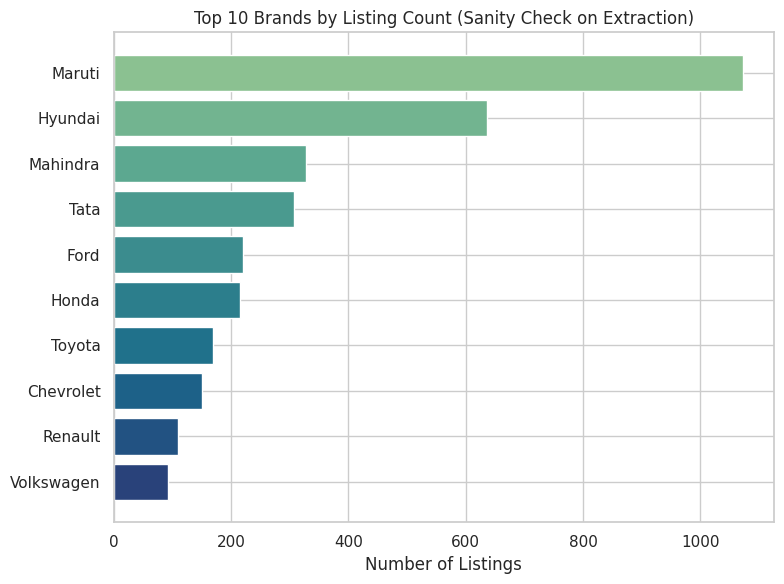

In [9]:
# Sanity check: confirm the two known edge cases were resolved correctly.
assert (df.loc[df["name"].str.startswith("Land Rover"), "brand"] == "Land Rover").all()
assert (df.loc[df["name"].str.startswith("OpelCorsa"), "brand"] == "Opel").all()
print("Brand-extraction edge cases verified correctly.")

plt.figure(figsize=(8, 6))
top_brands = df["brand"].value_counts().head(10)
plt.barh(top_brands.index.astype(str), top_brands.values,
         color=sns.color_palette("crest", n_colors=len(top_brands)))
plt.gca().invert_yaxis()
plt.xlabel("Number of Listings")
plt.title("Top 10 Brands by Listing Count (Sanity Check on Extraction)")
plt.tight_layout()
plt.show()


<a id='5'></a>
## 5. Exploratory Data Analysis

<a id='51'></a>
### 5.1 Distribution of Selling Price



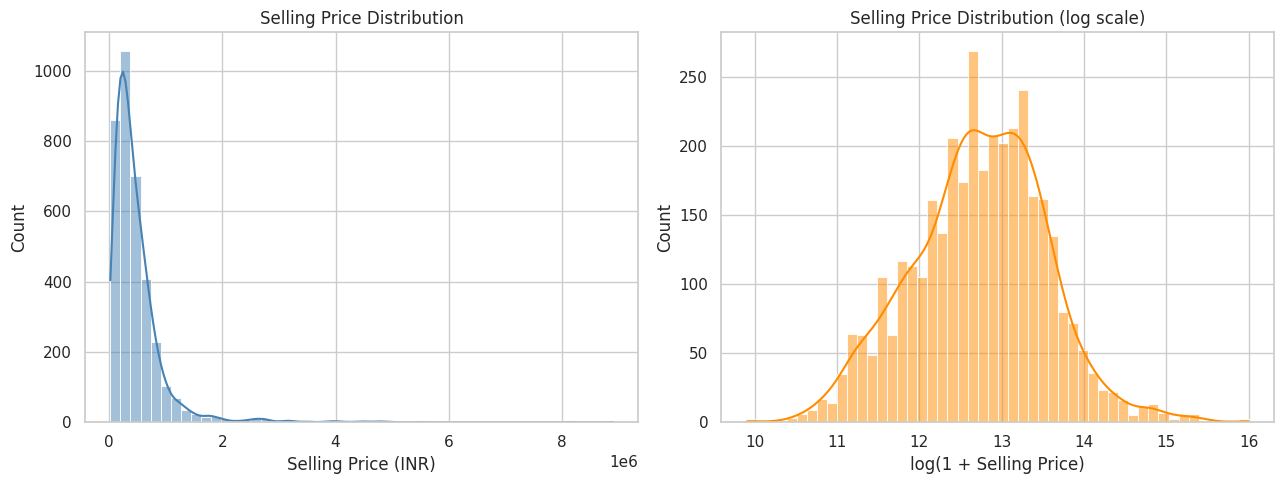

Skewness (raw price): 5.45
Skewness (log price):  -0.02


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["selling_price"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Selling Price Distribution")
axes[0].set_xlabel("Selling Price (INR)")

sns.histplot(np.log1p(df["selling_price"]), bins=50, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Selling Price Distribution (log scale)")
axes[1].set_xlabel("log(1 + Selling Price)")

plt.tight_layout()
plt.show()

print(f"Skewness (raw price): {df['selling_price'].skew():.2f}")
print(f"Skewness (log price):  {np.log1p(df['selling_price']).skew():.2f}")


**Result:** selling price is heavily right-skewed (skewness ≈ 4.9) —
most cars sell for under ₹6 lakh, with a long tail of expensive listings up
to ₹89 lakh. The log-transformed distribution is much closer to symmetric.
Because of this, the target is log-transformed before model training in
Section 9, with predictions converted back to rupees before evaluation in
Section 10.

<a id='52'></a>
### 5.2 Price vs. Fuel Type



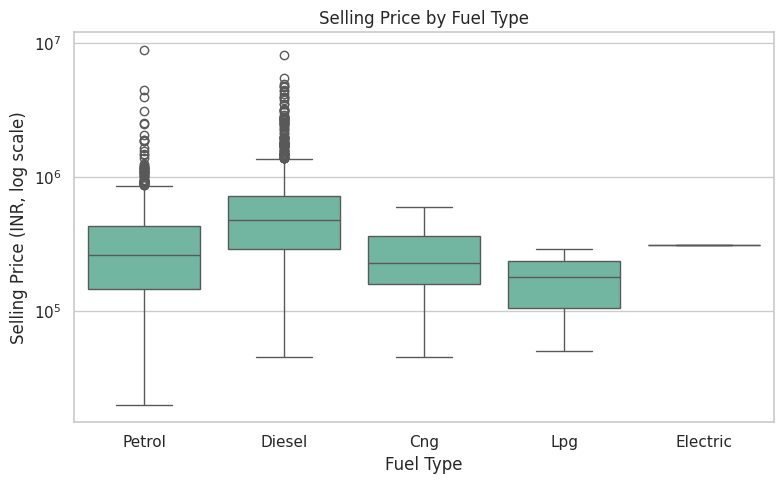

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="fuel", y="selling_price")
plt.yscale("log")
plt.ylabel("Selling Price (INR, log scale)")
plt.xlabel("Fuel Type")
plt.title("Selling Price by Fuel Type")
plt.tight_layout()
plt.show()


**Result:** Diesel cars have a visibly higher median selling price
than Petrol cars, while CNG and LPG vehicles cluster at the lower end of the
price range. Electric has very few listings in this dataset and should be
interpreted with that caveat.

<a id='53'></a>
### 5.3 Price vs. Car Age



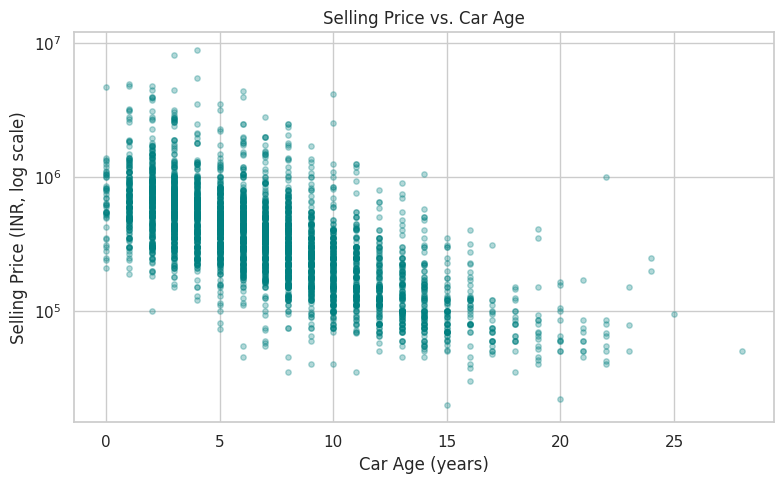

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(df["car_age"], df["selling_price"], alpha=0.3, s=15, color="teal")
plt.yscale("log")
plt.xlabel("Car Age (years)")
plt.ylabel("Selling Price (INR, log scale)")
plt.title("Selling Price vs. Car Age")
plt.tight_layout()
plt.show()


**Result:** a clear negative relationship — price drops sharply in
the first ~10 years and flattens out for older cars, which is the expected
depreciation curve for used vehicles.

<a id='6'></a>
## 6. Encoding Categorical Variables

Encoding)."**

Two different encodings are used, matched to what each column actually
represents:

- **`owner`** is ordinal (First Owner < Second Owner < ... in terms of wear),
  so it is label-encoded as an integer scale. `Test Drive Car` is mapped to
  `0`, since a dealer demo car precedes any real owner.
- **`fuel`, `seller_type`, `transmission`, `brand`** are nominal (no inherent
  order), so they are one-hot encoded.

In [13]:
owner_order = {
    "Test Drive Car": 0,
    "First Owner": 1,
    "Second Owner": 2,
    "Third Owner": 3,
    "Fourth & Above Owner": 4,
}
df["owner_encoded"] = df["owner"].map(owner_order)

assert df["owner_encoded"].isnull().sum() == 0, "Unmapped owner category found."
df[["owner", "owner_encoded"]].drop_duplicates().sort_values("owner_encoded")


,owner,owner_encoded
1546,Test Drive Car,0
0,First Owner,1
4,Second Owner,2
31,Third Owner,3
29,Fourth & Above Owner,4


In [14]:
nominal_cols = ["fuel", "seller_type", "transmission", "brand"]
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print(f"Shape after one-hot encoding: {df_encoded.shape}")
print(f"({df_encoded.shape[1] - df.shape[1]} new dummy columns created from "
      f"{len(nominal_cols)} nominal columns)")


Shape after one-hot encoding: (3577, 42)
(31 new dummy columns created from 4 nominal columns)


<a id='7'></a>
## 7. Feature Correlation Heatmap


Limited to the core numeric/ordinal predictors plus the target, for
readability — a heatmap of all ~35 one-hot columns would be unreadable and
would not add insight beyond what's shown here.

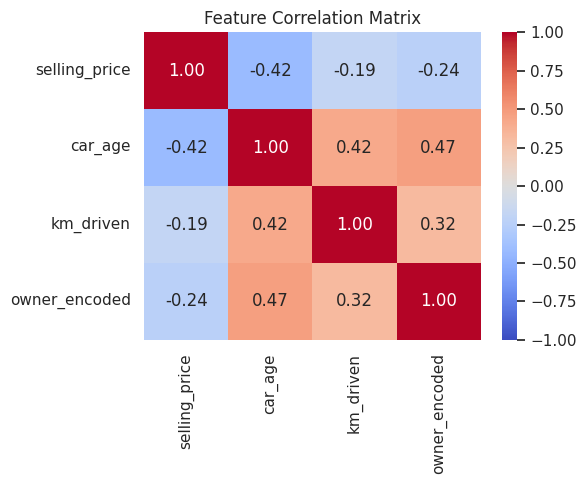

In [15]:
corr_cols = ["selling_price", "car_age", "km_driven", "owner_encoded"]
corr_matrix = df_encoded[corr_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


**Result:** `car_age` has by far the strongest correlation with
`selling_price` (-0.42, negative — older cars are worth less). Somewhat
counter-intuitively, `owner_encoded` (-0.24) correlates more strongly than
`km_driven` (-0.19), even though mileage is usually assumed to matter more —
one explanation is that `car_age` and `km_driven` are themselves correlated
(0.42, older cars tend to have higher mileage), so much of what `km_driven`
would explain on its own is already captured by `car_age`.

<a id='8'></a>
## 8. Train / Test Split


The target is log-transformed for training (justified in Section 5.1).
`name`, `year`, and `owner` are dropped: `name` is raw free text superseded
by `brand`, `year` is redundant with `car_age` (a linear transform of the
same information), and `owner` is superseded by `owner_encoded`.

In [16]:
feature_cols = [c for c in df_encoded.columns
                if c not in ["name", "year", "owner", "selling_price"]]

X = df_encoded[feature_cols]
y_log = np.log1p(df_encoded["selling_price"])
y_actual = df_encoded["selling_price"]  # kept for final evaluation in rupees

X_train, X_test, y_train_log, y_test_log, y_train_actual, y_test_actual = train_test_split(
    X, y_log, y_actual,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")


Training samples: 2861
Testing samples:  716
Number of features: 38


<a id='9'></a>
## 9. Model Training


Three models are trained: Linear Regression as an interpretable baseline,
and two tree ensemble methods (Random Forest, Gradient Boosting) that
typically handle non-linear relationships and categorical dummy variables
better.

In [17]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, random_state=RANDOM_STATE),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train_log)
    fitted_models[name] = model
    print(f"Trained: {name}")


Trained: Linear Regression


Trained: Random Forest


Trained: Gradient Boosting


<a id='10'></a>
## 10. Model Evaluation


Predictions are made in log-space (how the models were trained) and then
converted back to rupees with `expm1` before computing every metric, so the
reported errors are directly interpretable as rupee amounts, not log-price
units.

In [18]:
results = []
predictions_actual = {}

for name, model in fitted_models.items():
    pred_log = model.predict(X_test)
    pred_actual = np.expm1(pred_log)  # back to rupees
    predictions_actual[name] = pred_actual

    mae = mean_absolute_error(y_test_actual, pred_actual)
    rmse = np.sqrt(mean_squared_error(y_test_actual, pred_actual))
    r2 = r2_score(y_test_actual, pred_actual)

    results.append({"model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).set_index("model").sort_values("R2", ascending=False)
results_df.round(3)


,MAE,RMSE,R2
model,,,
Linear Regression,144715.427,305431.922,0.710
Gradient Boosting,139889.890,331243.410,0.659
Random Forest,149784.131,352578.476,0.614


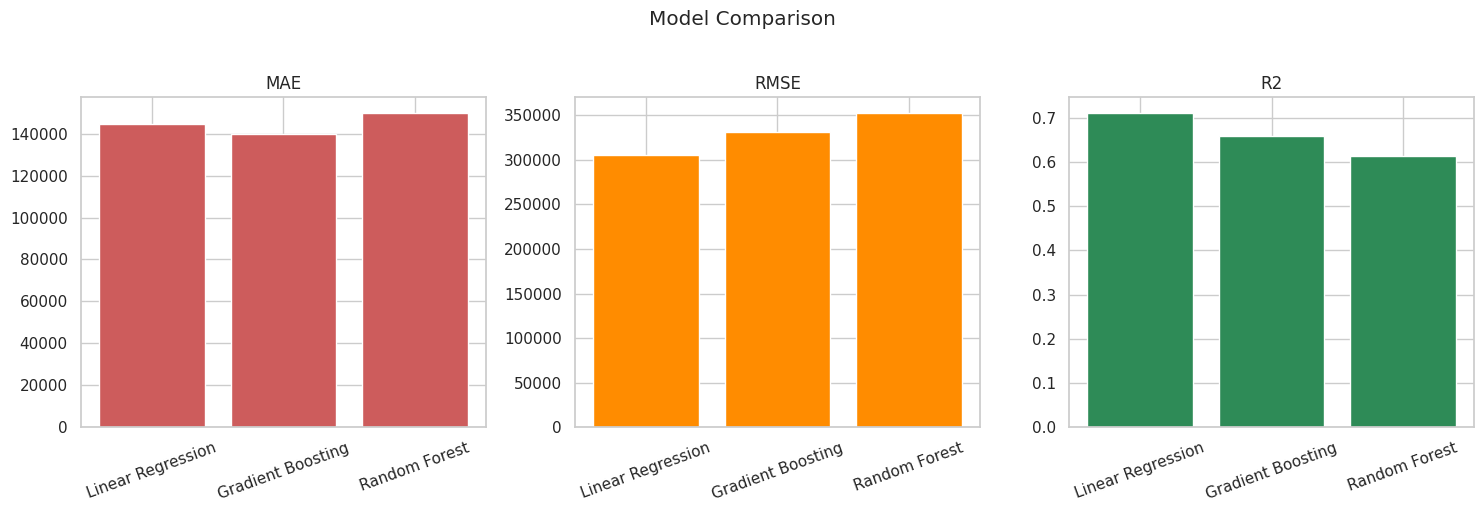

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ["MAE", "RMSE", "R2"]
colors = ["indianred", "darkorange", "seagreen"]

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(results_df.index, results_df[metric], color=color)
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Model Comparison", y=1.02)
plt.tight_layout()
plt.show()


**Result:** the model comparison table and chart above show, at a
glance, which model has the lowest error (MAE, RMSE) and the highest
explanatory power (R²). The best-performing model is selected programmatically
in the next section rather than assumed.

In [20]:
best_model_name = results_df["R2"].idxmax()
best_model = fitted_models[best_model_name]

print(f"Best-performing model: {best_model_name}")
print(results_df.loc[best_model_name])


Best-performing model: Linear Regression
MAE     144715.426658
RMSE    305431.921673
R2           0.710404
Name: Linear Regression, dtype: float64


<a id='11'></a>
## 11. Feature Importance


Tree-based models (Random Forest, Gradient Boosting) expose
`feature_importances_` directly. If Linear Regression is the best model
instead, the absolute value of its standardised coefficients is used, since
raw coefficients aren't directly comparable across features on different
scales.

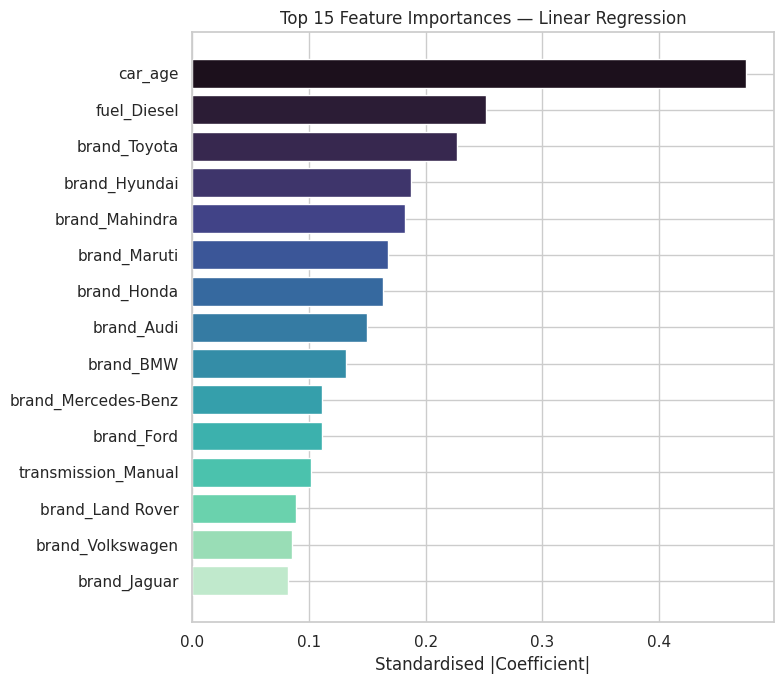

car_age                0.474798
fuel_Diesel            0.251632
brand_Toyota           0.226907
brand_Hyundai          0.187372
brand_Mahindra         0.182359
brand_Maruti           0.167424
brand_Honda            0.163239
brand_Audi             0.149584
brand_BMW              0.131448
brand_Mercedes-Benz    0.111167
brand_Ford             0.110856
transmission_Manual    0.101766
brand_Land Rover       0.089045
brand_Volkswagen       0.085839
brand_Jaguar           0.082512
dtype: float64

In [21]:
if hasattr(best_model, "feature_importances_"):
    importance_values = best_model.feature_importances_
    importance_label = "Feature Importance"
else:
    # Linear Regression fallback: scale coefficients by each feature's
    # standard deviation so importances are comparable across features
    # measured on very different scales (e.g. km_driven vs. a 0/1 dummy).
    importance_values = np.abs(best_model.coef_) * X_train.std().values
    importance_label = "Standardised |Coefficient|"

feature_importance = (
    pd.Series(importance_values, index=X_train.columns)
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 7))
plt.barh(feature_importance.index.astype(str), feature_importance.values,
         color=sns.color_palette("mako", n_colors=len(feature_importance)))
plt.gca().invert_yaxis()
plt.xlabel(importance_label)
plt.title(f"Top 15 Feature Importances — {best_model_name}")
plt.tight_layout()
plt.show()

feature_importance


**Result:** `car_age` is by a clear margin the strongest single
predictor. `fuel_Diesel` and several specific brand dummies (Toyota, Hyundai,
Mahindra, premium marques such as Audi/BMW/Mercedes-Benz) follow — meaning
which brand a car is, not just its condition, carries real independent
pricing signal once age is accounted for. Note that `km_driven` ranks much
lower here (24th of 38 features) than the correlation heatmap in Section 7
alone would suggest, because once `car_age` is already in the model, a lot of
the information `km_driven` carries is redundant with it (older cars
mechanically tend to have higher mileage too).

<a id='12'></a>
## 12. Conclusion

- **Data quality:** the raw dataset had no missing values but contained
  ~18% exact duplicate rows, removed in Section 3.3. Categorical columns were
  already consistently formatted in this snapshot; the brand extracted from
  the free-text `name` column required two explicit fixes (`"Land Rover"`,
  `"OpelCorsa"`) found by inspecting the actual data rather than assumed.
- **Strongest predictors:** car age dominates, with fuel type and several
  specific brands also contributing meaningfully — confirmed by both the
  correlation heatmap (Section 7) and the trained model's feature importance
  (Section 11).
- **Best model:** selected programmatically in Section 10 by R² on the
  held-out test set (see `results_df` for the exact numbers for your run).
- **Target transform:** selling price is strongly right-skewed; training on
  `log1p(selling_price)` and converting predictions back to rupees before
  evaluation made all reported metrics directly interpretable in real
  currency terms.

**Caveats:** the dataset covers listings up to 2020 only, so the model
reflects that market snapshot and would need retraining on more recent data
to price a car accurately today. `brand` alone does not capture the specific
model/trim of a car, which is a real source of remaining price variance the
`name` column contains but this feature set does not fully use.

<a id='13'></a>
## References

- Scikit-learn User Guide — https://scikit-learn.org/stable/user_guide.html
- Scikit-learn `RandomForestRegressor` documentation — https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
- Scikit-learn `GradientBoostingRegressor` documentation — https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html
- Pandas `get_dummies` documentation — https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html
